# **Comparing all the models to find the best one**

(Given the copies of plots in the markdown, if it's not visible in git or editors)

## **Imports**

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

import torch
import torch.nn as nn
from IPython.display import display

## **Loading the data**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/oil_prices_2426.csv")
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").set_index("date")

y = df["price (dollars)"].astype(float).asfreq("D")

print("Loaded")
print("Start:", y.index.min(), "| End:", y.index.max(), "| n:", len(y))

Loaded
Start: 2024-09-21 00:00:00 | End: 2026-02-02 00:00:00 | n: 500


## **Train/Val/Test split**

In [ ]:
TEST_DAYS = 90
VAL_DAYS = 60

y_train_full = y.iloc[:-TEST_DAYS]
y_test = y.iloc[-TEST_DAYS:]

y_train_core = y_train_full.iloc[:-VAL_DAYS]
y_val = y_train_full.iloc[-VAL_DAYS:]

print("Train core:", len(y_train_core))
print("Validation:", len(y_val))
print("Test:", len(y_test))

fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train_core.index, y=y_train_core.values, name="Train core", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_val.index, y=y_val.values, name="Validation", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=y_test.values, name="Test", line=dict(width=2)))
fig.update_layout(
    template="plotly_white",
    title=dict(text="Train / Validation / Test split", x=0.5),
    xaxis_title="Date",
    yaxis_title="USD",
    font=dict(size=14),
    margin=dict(l=60, r=30, t=70, b=60),
)
fig.show()

Train core: 350
Validation: 60
Test: 90


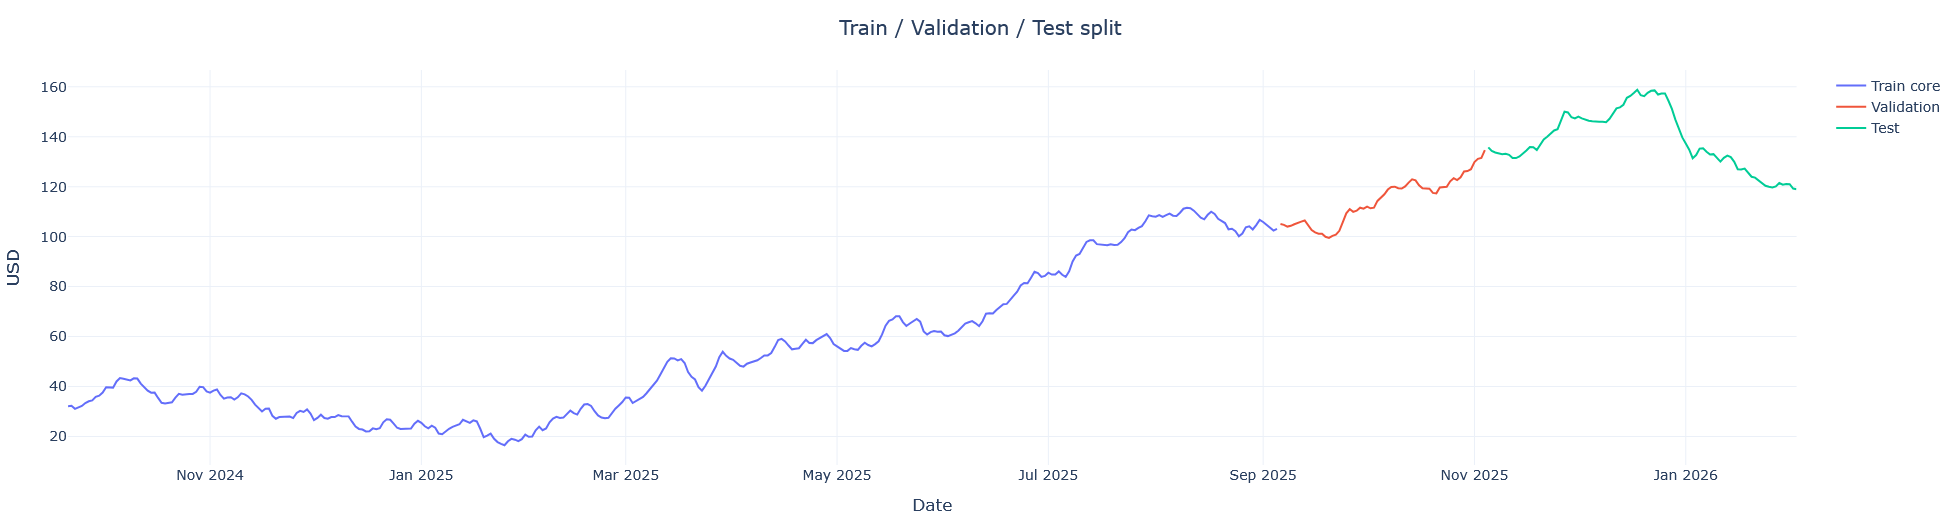

## **Defining Evaluation metrics**

In [ ]:
def rmse(y_true, y_pred):
    """
    Return root mean squared error (RMSE) between y_true and y_pred
    """
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    """
    Return mean absolute error (MAE) between y_true and y_pred
    """
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return float(mean_absolute_error(y_true, y_pred))

def smape(y_true, y_pred, eps=1e-8):
    """
    Return symmetric MAPE (sMAPE) in percent, using a small eps to avoid divide-by-zero
    """
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)

## **Loading the pretrained Delta LSTM**

In [ ]:
payload_lstm = torch.load("/content/drive/MyDrive/lstm_delta.pt", map_location="cpu", weights_only=False)

LOOKBACK = int(payload_lstm["lookback"])
scaler_mean = float(np.asarray(payload_lstm["scaler_mean"]).ravel()[0])
scaler_scale = float(np.asarray(payload_lstm["scaler_scale"]).ravel()[0])
lo_clip, hi_clip = payload_lstm["clip_bounds"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("LSTM lookback:", LOOKBACK)
print("Scaler mean/std:", scaler_mean, scaler_scale)
print("Clip bounds:", lo_clip, hi_clip)

class DeltaLSTM(nn.Module):
    """
    Pretrained LSTM used to predict the next scaled delta from a lookback window of past deltas
    """
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

lstm_model = DeltaLSTM(hidden=32)
lstm_model.load_state_dict(payload_lstm["state_dict"])
lstm_model = lstm_model.to(DEVICE)
lstm_model.eval()

Device: cuda
LSTM lookback: 30
Scaler mean/std: 0.2506112469437653 1.360156710362421
Clip bounds: -2.9292000000000034 3.4588000000000143


DeltaLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## **Defining the 1-step rolling pred functions for Delta LSTM**

In [ ]:
def inv_scale_delta(ds):
    """
    Convert a scaled delta back to the original delta units using the saved mean/std
    """
    return ds * scaler_scale + scaler_mean

def build_delta_series(series: pd.Series):
    """
    Compute 1-day price differences (deltas) from a level series
    """
    return series.diff().dropna()

def lstm_predict_delta_from_history(full_y: pd.Series, target_date: pd.Timestamp):
    """
    Predict the delta for target_date using only data up to target_date-1
    """
    hist = full_y.loc[:target_date - pd.Timedelta(days=1)]
    dy = build_delta_series(hist)

    window = dy.values[-LOOKBACK:].astype(np.float32)
    window_s = ((window - scaler_mean) / scaler_scale).astype(np.float32)

    x = torch.from_numpy(window_s.reshape(1, LOOKBACK, 1)).to(DEVICE)
    with torch.no_grad():
        d_s = float(lstm_model(x).cpu().numpy().item())

    d = float(inv_scale_delta(d_s))
    d = float(np.clip(d, lo_clip, hi_clip))
    return d

def lstm_rolling_1step_prices(full_y: pd.Series, eval_dates: pd.DatetimeIndex):
    """
    Generate rolling 1-step price forecasts by predicting deltas and adding them to the previous price
    """
    preds = []
    for t in eval_dates:
        d_hat = lstm_predict_delta_from_history(full_y, t)
        prev_price = float(full_y.loc[t - pd.Timedelta(days=1)])
        preds.append(prev_price + d_hat)
    return np.array(preds, float)

## **Defining ARIMA order search and its 1-step predictions**

In [ ]:
def arima_order_search_on_returns(y_series: pd.Series, p_max=6, q_max=6):
    """
    Select the best ARIMA(p,0,q) on log returns by scanning a (p,q) grid and minimizing AIC
    """
    lp = np.log(y_series)
    r = lp.diff().dropna()

    best_aic = np.inf
    best_order = None
    best_res = None

    for p in range(p_max + 1):
        for q in range(q_max + 1):
            try:
                res = ARIMA(
                    r,
                    order=(p, 0, q),
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, 0, q)
                    best_res = res
            except Exception:
                continue

    return best_order, best_aic, best_res

def arima_rolling_1step_prices(full_y: pd.Series, train_end_date: pd.Timestamp, eval_dates: pd.DatetimeIndex, order):
    """
    Roll 1-step ARIMA forecasts on log returns and convert each predicted return back to a price forecast
    """
    lp = np.log(full_y)
    r = lp.diff().dropna()

    r_train = r.loc[:train_end_date].copy()
    if r_train.name is None:
        r_train.name = "r"

    res_roll = ARIMA(
        r_train,
        order=order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    preds = []

    for t in eval_dates:
        fc = res_roll.get_forecast(steps=1)
        r_hat = float(fc.predicted_mean.iloc[0])

        prev_price = float(full_y.loc[t - pd.Timedelta(days=1)])
        preds.append(prev_price * np.exp(r_hat))

        obs_r = float(r.loc[t])
        obs_series = pd.Series([obs_r], index=[t], name=r_train.name)

        try:
            if hasattr(res_roll, "append"):
                res_roll = res_roll.append(obs_series, refit=False)
            elif hasattr(res_roll, "extend"):
                res_roll = res_roll.extend(obs_series)
            else:
                raise AttributeError("No append/extend")
        except Exception:
            sub = r.loc[:t].copy()
            sub.name = r_train.name
            res_roll = ARIMA(
                sub,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()

    return np.array(preds, float)

## **Defining the dynamic mixture for the Kenshi model**

In [ ]:
def _softmax_pair(sa, sb):
    """
    Compute a numerically stable 2-value softmax that returns weights summing to 1
    """
    m = max(sa, sb)
    ea = np.exp(sa - m)
    eb = np.exp(sb - m)
    z = ea + eb
    return ea / z, eb / z

def kenshi_predict(y_true, pred_arima, pred_lstm, lam=0.90, gamma=6.0, rho=0.80, disagree_penalty=0.10, vol_window=7, clip_bias=3.0):
    """
    Produce Kenshi forecasts by weighting ARIMA/LSTM using recent squared-error memory and a clipped bias term
    """
    y_true = np.asarray(y_true, float)
    pred_arima = np.asarray(pred_arima, float)
    pred_lstm = np.asarray(pred_lstm, float)

    n = len(y_true)
    out = np.zeros(n, float)
    s_a = 1.0
    s_l = 1.0
    bias = 0.0

    e_a_prev = 0.0
    e_l_prev = 0.0
    e_h_prev = 0.0

    wL = np.zeros(n, float)
    wA = np.zeros(n, float)
    b_hist = np.zeros(n, float)

    dy = np.diff(y_true, prepend=y_true[0])

    for t in range(n):
        if t > 0:
            s_a = lam * s_a + (1 - lam) * (e_a_prev ** 2)
            s_l = lam * s_l + (1 - lam) * (e_l_prev ** 2)
            bias = rho * bias + (1 - rho) * e_h_prev

        lo = max(0, t - vol_window)
        vol_t = np.std(dy[lo:t+1]) if t > 0 else np.std(dy[:min(n, vol_window+1)])
        vol_t = float(max(vol_t, 1e-6))

        score_l = -gamma * s_l
        score_a = -gamma * s_a
        w_l, w_a = _softmax_pair(score_l, score_a)

        d = pred_lstm[t] - pred_arima[t]
        if abs(d) > 2.0 * vol_t:
            w_l = max(0.0, w_l - disagree_penalty)
            w_a = 1.0 - w_l

        bias_used = float(np.clip(bias, -clip_bias * vol_t, clip_bias * vol_t))

        y_hat = w_l * pred_lstm[t] + w_a * pred_arima[t] + bias_used
        out[t] = max(0.0, y_hat)

        e_a_prev = y_true[t] - pred_arima[t]
        e_l_prev = y_true[t] - pred_lstm[t]
        e_h_prev = y_true[t] - out[t]

        wL[t] = w_l
        wA[t] = w_a
        b_hist[t] = bias_used

    return out, wL, wA, b_hist

## **Validation preds for ARIMA and LSTM**

In [ ]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

best_arima_order, best_arima_aic, _ = arima_order_search_on_returns(y_train_core, p_max=6, q_max=6)
print("Best ARIMA order on train core:", best_arima_order, "| AIC:", best_arima_aic)

arima_val_pred = arima_rolling_1step_prices(
    full_y=y.loc[:y_val.index.max()],
    train_end_date=y_train_core.index.max(),
    eval_dates=y_val.index,
    order=best_arima_order
)

lstm_val_pred = lstm_rolling_1step_prices(
    full_y=y.loc[:y_val.index.max()],
    eval_dates=y_val.index
)

y_val_true = y_val.values.astype(float)

print("Validation RMSE - ARIMA:", rmse(y_val_true, arima_val_pred))
print("Validation RMSE - LSTM :", rmse(y_val_true, lstm_val_pred))

Best ARIMA order on train core: (2, 0, 1) | AIC: -1516.6260739358145
Validation RMSE - ARIMA: 0.9620058773003469
Validation RMSE - LSTM : 0.9738689755797787


## **Hyperparameter tuning for Kenshi on validation split**

In [ ]:
grid_lam = [0.80, 0.90, 0.95]
grid_gamma = [2.0, 4.0, 6.0, 8.0]
grid_rho = [0.50, 0.80, 0.90]
grid_pen = [0.00, 0.05, 0.10, 0.15]

best_cfg = None
best_val_rmse = np.inf

for lam in grid_lam:
    for gamma in grid_gamma:
        for rho in grid_rho:
            for pen in grid_pen:
                pred_h, _, _, _ = kenshi_predict(
                    y_true=y_val_true,
                    pred_arima=arima_val_pred,
                    pred_lstm=lstm_val_pred,
                    lam=lam,
                    gamma=gamma,
                    rho=rho,
                    disagree_penalty=pen,
                )
                score = rmse(y_val_true, pred_h)
                if score < best_val_rmse:
                    best_val_rmse = score
                    best_cfg = dict(lam=lam, gamma=gamma, rho=rho, disagree_penalty=pen)

print("Best Kenshi config:", best_cfg)
print("Validation RMSE - Kenshi:", best_val_rmse)

Best Kenshi config: {'lam': 0.8, 'gamma': 8.0, 'rho': 0.9, 'disagree_penalty': 0.0}
Validation RMSE - Kenshi: 0.960990585940853


## **Test set predictions for all three models**

In [ ]:
arima_test_pred = arima_rolling_1step_prices(
    full_y=y,
    train_end_date=y_train_full.index.max(),
    eval_dates=y_test.index,
    order=best_arima_order
)

lstm_test_pred = lstm_rolling_1step_prices(
    full_y=y,
    eval_dates=y_test.index
)

y_test_true = y_test.values.astype(float)

kenshi_test_pred, wL_test, wA_test, b_test = kenshi_predict(
    y_true=y_test_true,
    pred_arima=arima_test_pred,
    pred_lstm=lstm_test_pred,
    **best_cfg
)

print("Test RMSE - ARIMA :", rmse(y_test_true, arima_test_pred))
print("Test RMSE - LSTM  :", rmse(y_test_true, lstm_test_pred))
print("Test RMSE - Kenshi:", rmse(y_test_true, kenshi_test_pred))

Test RMSE - ARIMA : 1.2076765439302346
Test RMSE - LSTM  : 1.1318238658286344
Test RMSE - Kenshi: 1.0934499434031064


## **A final table to declare the winner (After a lot experimentation/trail and error, Kenshi finally won 🥲)**

In [ ]:
preds = {
    "ARIMA": np.asarray(arima_test_pred, float),
    "Delta-LSTM": np.asarray(lstm_test_pred, float),
    "Kenshi": np.asarray(kenshi_test_pred, float),
}

rows = []
for name, p in preds.items():
    rows.append({
        "Model": name,
        "RMSE": rmse(y_test_true, p),
        "MAE": mae(y_test_true, p),
        "sMAPE_%": smape(y_test_true, p),
    })

df_cmp = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
winner = df_cmp.loc[df_cmp["RMSE"].idxmin(), "Model"]

def highlight_winner_row(row):
    return ["background-color: #b7f7c1" if row["Model"] == winner else "" for _ in row]

styled = (
    df_cmp.style
    .apply(highlight_winner_row, axis=1)
    .format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "sMAPE_%": "{:.2f}", "DirAcc": "{:.3f}"})
    .highlight_min(subset=["RMSE", "MAE", "sMAPE_%"], color="#b7f7c1")
)

display(styled)
print("Winner (lowest RMSE):", winner)

,Model,RMSE,MAE,sMAPE_%
0,Kenshi,1.0934,0.8628,0.62
1,Delta-LSTM,1.1318,0.8979,0.65
2,ARIMA,1.2077,0.9558,0.69


Winner (lowest RMSE): Kenshi


## **Plotting the actual series with the forecasts**

In [ ]:
dates = y_test.index
y_true = np.asarray(y_test_true, float)

fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=dates, y=y_true, name="Actual", line=dict(width=3)))
for name, p in preds.items():
    fig1.add_trace(go.Scatter(x=dates, y=p, name=name, line=dict(width=2)))

fig1.update_layout(
    template="plotly_white",
    title=dict(text="Test window: actual vs model forecasts", x=0.5),
    xaxis_title="Date",
    yaxis_title="USD",
    margin=dict(l=60, r=30, t=70, b=60),
)
fig1.show()

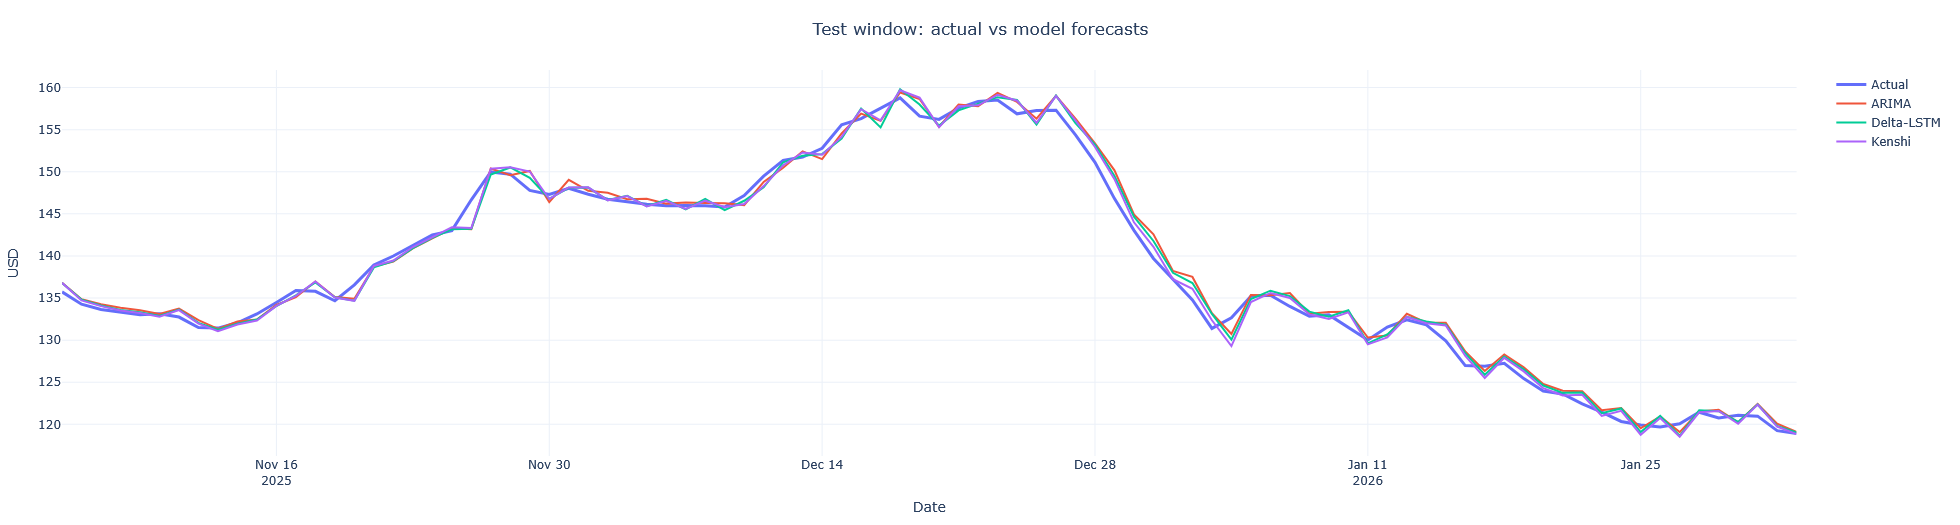

## **Plotting the absolute error by day**

In [ ]:
fig2 = go.Figure()
for name, p in preds.items():
    fig2.add_trace(go.Scatter(x=dates, y=np.abs(y_true - p), name=name, line=dict(width=2)))

fig2.update_layout(
    template="plotly_white",
    title=dict(text="Test window: absolute error by day", x=0.5),
    xaxis_title="Date",
    yaxis_title="|Error|",
    margin=dict(l=60, r=30, t=70, b=60),
)
fig2.show()

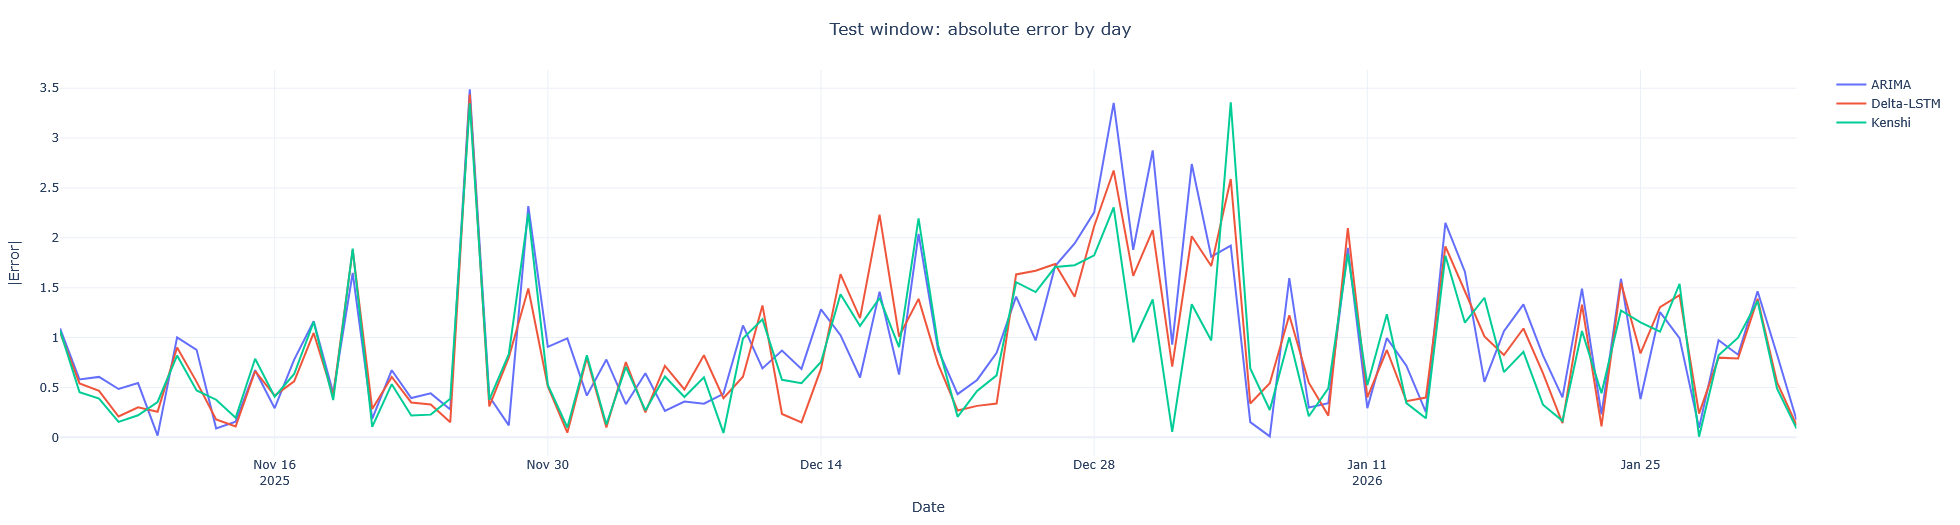

## **Plotting the cummulative squared error for all three models**

In [ ]:
fig3 = go.Figure()
for name, p in preds.items():
    cse = np.cumsum((y_true - p) ** 2)
    fig3.add_trace(go.Scatter(x=dates, y=cse, name=name, line=dict(width=2)))

fig3.update_layout(
    template="plotly_white",
    title=dict(text="Test window: cumulative squared error", x=0.5),
    xaxis_title="Date",
    yaxis_title="Cumulative (error^2)",
    margin=dict(l=60, r=30, t=70, b=60),
)
fig3.show()

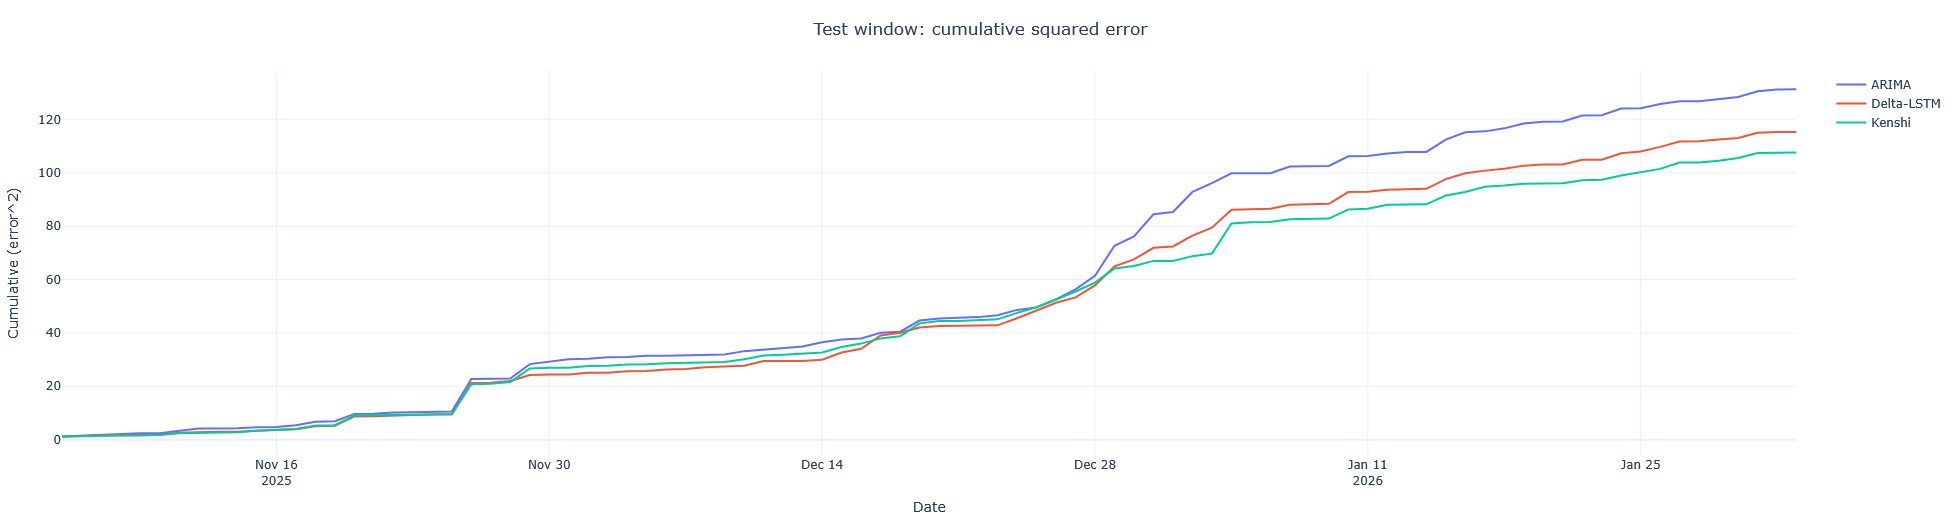